<a href="https://colab.research.google.com/github/Maryam-Skaik/customer-segmentation-kmeans/blob/main/notebook/KMeans_Clustering_(Core).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# KMeans Clustering (Core)

## Imports

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

## Load Dataset

In [2]:
df = pd.read_csv("https://assets.codingdojo.com/boomyeah2015/codingdojo/curriculum/content/chapter/cust_seg.csv")
df = df.drop(columns=['Unnamed: 0', 'Customer Id'])
df.head()

,Age,Edu,Years Employed,Income,Card Debt,Other Debt,Defaulted,DebtIncomeRatio
0,41,2,6,19,0.124,1.073,0.0,6.3
1,47,1,26,100,4.582,8.218,0.0,12.8
2,33,2,10,57,6.111,5.802,1.0,20.9
3,29,2,4,19,0.681,0.516,0.0,6.3
4,47,1,31,253,9.308,8.908,0.0,7.2


## Data Understanding

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 850 entries, 0 to 849
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Age              850 non-null    int64  
 1   Edu              850 non-null    int64  
 2   Years Employed   850 non-null    int64  
 3   Income           850 non-null    int64  
 4   Card Debt        850 non-null    float64
 5   Other Debt       850 non-null    float64
 6   Defaulted        700 non-null    float64
 7   DebtIncomeRatio  850 non-null    float64
dtypes: float64(4), int64(4)
memory usage: 53.3 KB


- Dataset conatins 850 rows and 8 columns

- `Defaulted` contains some missing values

- All features are numeric

In [4]:
df.describe().round(2)

,Age,Edu,Years Employed,Income,Card Debt,Other Debt,Defaulted,DebtIncomeRatio
count,850.00,850.00,850.00,850.00,850.00,850.00,700.00,850.00
mean,35.03,1.71,8.57,46.68,1.58,3.08,0.26,10.17
std,8.04,0.93,6.78,38.54,2.13,3.40,0.44,6.72
min,20.00,1.00,0.00,13.00,0.01,0.05,0.00,0.10
25%,29.00,1.00,3.00,24.00,0.38,1.05,0.00,5.10
50%,34.00,1.00,7.00,35.00,0.88,2.00,0.00,8.70
75%,41.00,2.00,13.00,55.75,1.90,3.90,1.00,13.80
max,56.00,5.00,33.00,446.00,20.56,35.20,1.00,41.30


In [5]:
df['Defaulted'] = df['Defaulted'].fillna(df['Defaulted'].median())
df.isna().sum().sum()

np.int64(0)

In [6]:
features = [
    "Age",
    "Edu",
    "Years Employed",
    "Income",
    "Card Debt",
    "Defaulted",
    "DebtIncomeRatio"
]

X = df[features]

## Scale Data

In [7]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled

array([[ 0.74291541,  0.31212243, -0.37878978, ..., -0.68381116,
        -0.52379654, -0.57652509],
       [ 1.48949049, -0.76634938,  2.5737211 , ...,  1.41447366,
        -0.52379654,  0.39138677],
       [-0.25251804,  0.31212243,  0.2117124 , ...,  2.13414111,
         1.90913822,  1.59755385],
       ...,
       [-1.24795149,  2.46906604, -1.26454304, ...,  0.5766659 ,
         1.90913822,  3.45892281],
       [-0.37694723, -0.76634938,  0.50696349, ..., -0.68757659,
        -0.52379654, -1.08281745],
       [ 2.1116364 , -0.76634938,  1.09746566, ...,  0.13611081,
        -0.52379654, -0.2340332 ]])

## Find Optimal K (Elbow + Silhouette)

### Elbow Method (Inertia)

In [8]:
ks = range(2, 11)
inertias = []

for k in ks:
    kmeans = KMeans(n_clusters=k, n_init='auto', random_state=42)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

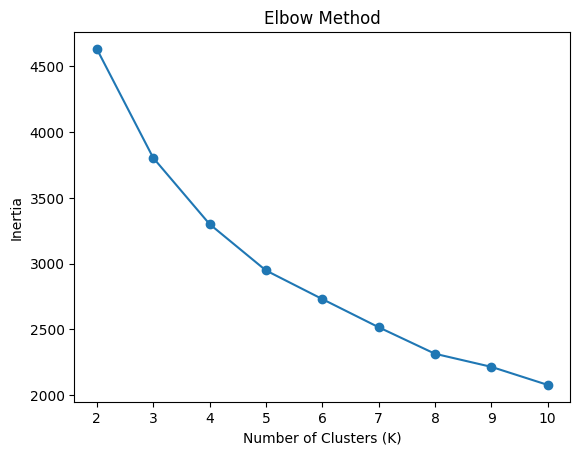

In [9]:
# Plot Elbow
plt.plot(ks, inertias, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

## Silhouette Score

In [10]:
sil_scores = []

for k in ks:
    kmeans = KMeans(n_clusters=k, n_init='auto', random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    sil_scores.append(score)

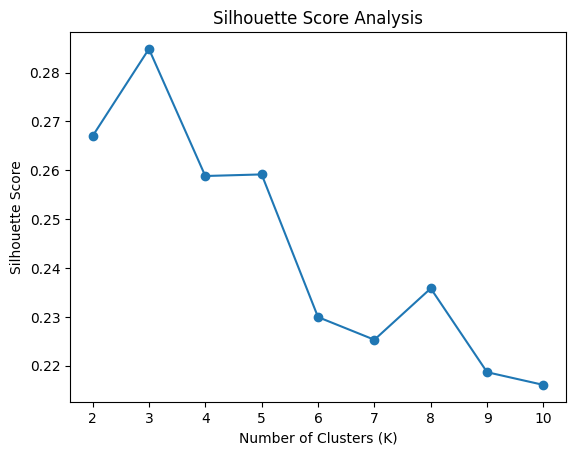

In [11]:
# Plot Silhouette
plt.plot(ks, sil_scores, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score Analysis")
plt.show()

## Train Final KMeans Model

In [12]:
kmeans = KMeans(n_clusters=3, n_init='auto', random_state=42)
kmeans.fit(X_scaled)

df["cluster"] = kmeans.labels_

In [13]:
df["cluster"].value_counts()

,count
cluster,
1,502
2,176
0,172


## Cluster Statistics

In [14]:
cluster_summary = df.groupby("cluster").mean()
cluster_summary

,Age,Edu,Years Employed,Income,Card Debt,Other Debt,Defaulted,DebtIncomeRatio
cluster,,,,,,,,
0,43.569767,1.802326,17.930233,97.401163,3.389785,6.214529,0.058140,10.683140
1,33.059761,1.615538,6.816733,33.735060,0.836538,1.922552,0.000000,8.401594
2,32.301136,1.892045,4.403409,34.011364,1.916545,3.312142,0.982955,14.720455


## Visualizing Cluster Behavior

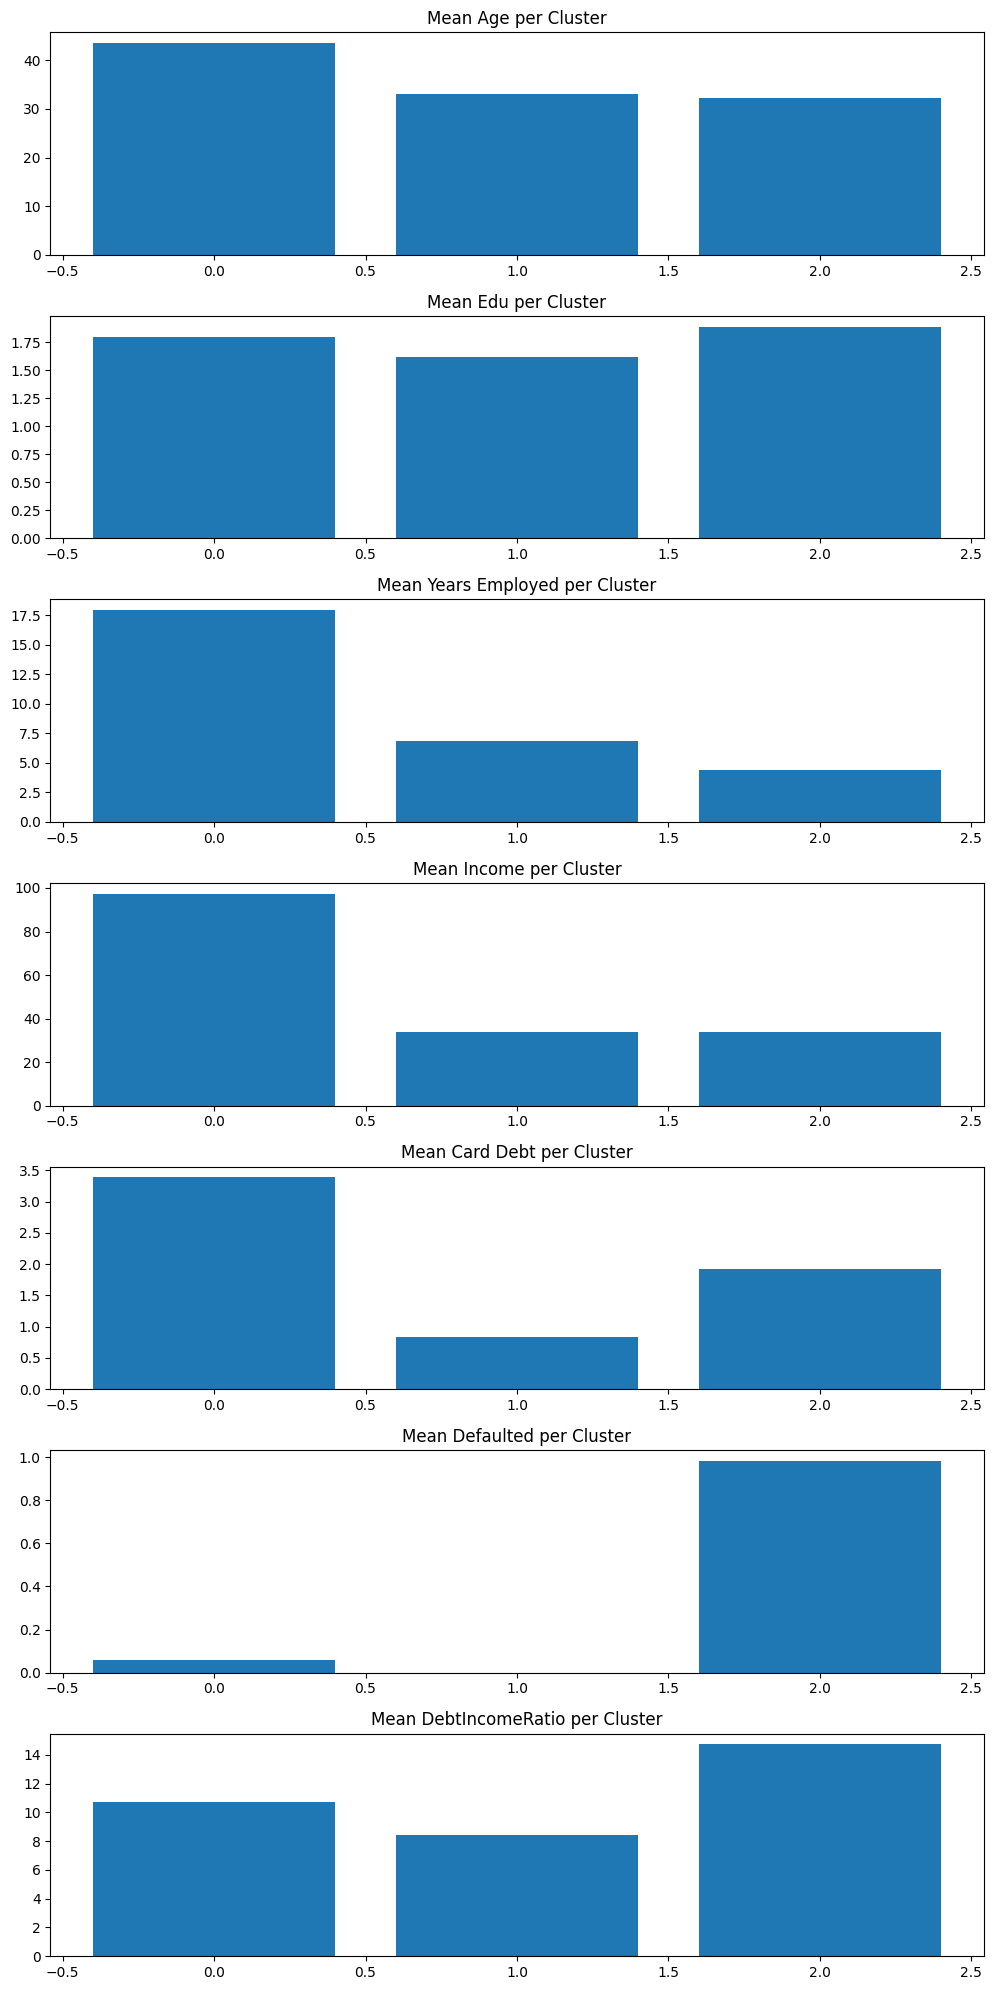

In [15]:
fig, axes = plt.subplots(len(features), 1, figsize=(10, 20))

for i, col in enumerate(features):
    axes[i].bar(cluster_summary.index, cluster_summary[col])
    axes[i].set_title(f"Mean {col} per Cluster")

plt.tight_layout()
plt.show()

### Cluster 0: High-Earning Stable Professionals

* Highest income group (around 90K–100K)
* Most work experience (around 15–18 years)
* Older customer segment overall
* Higher card debt, but manageable relative to income
* Very low default rate
* Overall financially stable with strong repayment ability

### Cluster 1: Low-Risk Conservative Customers

* Lowest income group (around 30K–40K)
* Moderate work experience (around 5–8 years)
* Younger than Cluster 0
* Low card debt compared to other clusters
* Lowest debt-to-income ratio
* Very low default rate
* Careful and controlled credit usage

### Cluster 2: High-Risk Financially Strained Customers

* Low to moderate income (similar to Cluster 1)
* Least work experience (around 3–5 years)
* Youngest or early-career group
* Highest debt-to-income ratio
* Highest default rate among all clusters
* Financial instability despite relatively higher education
* Likely struggling with debt management or financial planning

### Overall Key Insights

* Cluster 0: high-income, low-risk, stable customers
* Cluster 1: low-risk but low-value credit users
* Cluster 2: high-risk customers needing strict credit control
* Income alone does not determine risk level (seen in Cluster 2)
* Work experience is a strong indicator of financial stability

## Marketing Recommendations by Cluster

### Cluster 0: High-Earning Stable Customers

* Offer premium credit cards with high credit limits
* Provide travel rewards and cashback benefits
* Focus on loyalty programs and exclusive offers
* Build long-term customer relationships
* Offer premium financial and investment services

### Cluster 1: Low-Risk Regular Customers

* Offer standard credit cards with moderate limits
* Keep fees low or remove annual fees
* Provide cashback on daily purchases (food, fuel, shopping)
* Gradually increase credit limits with good usage
* Encourage basic financial education and credit building

### Cluster 2: High-Risk Customers

* Offer secured or low-limit credit cards only
* Use strict approval and risk control policies
* Avoid high credit exposure
* Provide budgeting and debt management tools
* Focus on improving financial stability before expansion